<h1>Capstone Project: The Impact of Weather on Flight Delays</h1>

<h2> Notebook 3 - Model on Data - 2022/23 as train and 2025 as test</h2> 

<h2>1. Load Data</h2>

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
#from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import make_scorer
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.inspection import permutation_importance

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier

from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
import xgboost as xgb


%matplotlib inline

# Set the style to whitegrid
sns.set_style("whitegrid")

In [2]:
# Set colour palette
palette = [
    "#4FA3C5",  # Glacier Lake Blue
    "#2E4259",  # Andean Slate
    "#7E9B6C",  # Moss Trail Green
    "#C7A76C",  # Autumn Grass
    "#D08159",  # Sunset Clay
    "#C9C5E0"   # Frost Lavender
]

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#F9FAFB",
        "grid.color": "#E6E6E6",
        "figure.facecolor": "white",
        "axes.edgecolor": "#DDDDDD",
        "font.size": 12,
        "axes.titlepad": 12,
        "axes.labelpad": 8,
        "axes.titleweight": "bold",
    }
)

sns.set_palette(palette)

In [3]:
# Read CSV

merged_df_2022_2023 = 'data/merged_df_2022_2023.csv' #train data

merged_df_2025 = 'data/merged_df_2025.csv' #future data for test


train_df = pd.read_csv(merged_df_2022_2023)
test_df = pd.read_csv(merged_df_2025)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261001 entries, 0 to 261000
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   flight_date          261001 non-null  object 
 1   tail_num             261001 non-null  object 
 2   op_carrier_fl_num    261001 non-null  int64  
 3   origin_airport_id    261001 non-null  int64  
 4   origin               261001 non-null  object 
 5   dest_airport_id      261001 non-null  int64  
 6   dest                 261001 non-null  object 
 7   crs_dep_time         261001 non-null  int64  
 8   dep_time             261001 non-null  int64  
 9   dep_delay            261001 non-null  int64  
 10  cancelled            261001 non-null  float64
 11  diverted             261001 non-null  float64
 12  carrier_delay        261001 non-null  float64
 13  weather_delay        261001 non-null  float64
 14  nas_delay            261001 non-null  float64
 15  security_delay   

In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85435 entries, 0 to 85434
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flight_date          85435 non-null  object 
 1   tail_num             85435 non-null  object 
 2   op_carrier_fl_num    85435 non-null  int64  
 3   origin_airport_id    85435 non-null  int64  
 4   origin               85435 non-null  object 
 5   dest_airport_id      85435 non-null  int64  
 6   dest                 85435 non-null  object 
 7   crs_dep_time         85435 non-null  int64  
 8   dep_time             85435 non-null  int64  
 9   dep_delay            85435 non-null  int64  
 10  cancelled            85435 non-null  float64
 11  diverted             85435 non-null  float64
 12  carrier_delay        85435 non-null  float64
 13  weather_delay        85435 non-null  float64
 14  nas_delay            85435 non-null  float64
 15  security_delay       85435 non-null 

In [6]:
# Instantiate and Fit the Encoder on Training Data
# a weather condition code, not a magnitude.
categorical_cols = ['coco']

In [7]:
# Instantiate and Fit the Encoder on Training Data
"""
Import OneHotEncoder and fit it only on the training data's categorical columns. 
This captures all unique categories present in the training set.
"""
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train_df[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [8]:
# Transform Both Datasets Use the same fitted encoder instance to transform both the training and test data.

# Transform training data
train_encoded_cols = encoder.transform(train_df[categorical_cols])
# Transform test data
test_encoded_cols = encoder.transform(test_df[categorical_cols])

In [9]:
# Convert to DataFrames and Reintegrate

# Get new column names
new_col_names = encoder.get_feature_names_out(categorical_cols)

# Create DataFrames
train_encoded_df = pd.DataFrame(train_encoded_cols, columns=new_col_names, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded_cols, columns=new_col_names, index=test_df.index)

# Drop original categorical columns from main DataFrames
train_df = train_df.drop(columns=categorical_cols)
test_df = test_df.drop(columns=categorical_cols)

# Concatenate the new one-hot encoded columns
train_final = pd.concat([train_df, train_encoded_df], axis=1)
test_final = pd.concat([test_df, test_encoded_df], axis=1)

In [10]:
train_final.sample(5)

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,coco_9,coco_10,coco_12,coco_13,coco_14,coco_15,coco_16,coco_17,coco_18,coco_25
104020,10/17/2022 12:00:00 AM,N949JT,1311,12478,JFK,12889,LAS,1100,1054,-6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
141305,1/29/2023 12:00:00 AM,N105HQ,4560,12478,JFK,11278,DCA,1545,1545,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26301,3/18/2022 12:00:00 AM,N928XJ,5273,12478,JFK,11193,CVG,1850,1844,-6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
220157,9/4/2023 12:00:00 AM,N6704Z,2204,12478,JFK,10397,ATL,600,559,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36199,4/15/2022 12:00:00 AM,N854NN,2836,12478,JFK,12889,LAS,1830,757,807,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
test_final.sample(5)

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,coco_9,coco_10,coco_12,coco_13,coco_14,coco_15,coco_16,coco_17,coco_18,coco_25
46734,6/17/2025 12:00:00 AM,N431YX,4734,12478,JFK,14122,PIT,1440,1517,37,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58366,7/29/2025 12:00:00 AM,N424YX,4538,12478,JFK,11278,DCA,630,628,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36702,5/13/2025 12:00:00 AM,N3242J,97,12478,JFK,11292,DEN,2020,2019,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60706,8/6/2025 12:00:00 AM,N1602,636,12478,JFK,12173,HNL,900,931,31,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54244,7/14/2025 12:00:00 AM,N860DN,2323,12478,JFK,10423,AUS,1135,1127,-8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<h2>2. Prepare the data and reporting</h2> 

<h3>2.1. Define target variables</h3>

In [12]:
# Checking columns list in the  df
train_final.columns.tolist()

['flight_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'scheduled_dep_dt',
 'weather_time',
 'temp',
 'rhum',
 'prcp',
 'wdir',
 'wspd',
 'pres',
 'cldc',
 'cldc_missing',
 'delayed_15',
 'wdir_bin_eda',
 'wdir_rad',
 'wdir_sin',
 'wdir_cos',
 'coco_0',
 'coco_1',
 'coco_2',
 'coco_3',
 'coco_4',
 'coco_5',
 'coco_7',
 'coco_8',
 'coco_9',
 'coco_10',
 'coco_12',
 'coco_13',
 'coco_14',
 'coco_15',
 'coco_16',
 'coco_17',
 'coco_18',
 'coco_25']

In [13]:
# Checking columns list in the  df
test_final.columns.tolist()

['flight_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'scheduled_dep_dt',
 'weather_time',
 'temp',
 'rhum',
 'prcp',
 'wdir',
 'wspd',
 'pres',
 'cldc',
 'cldc_missing',
 'delayed_15',
 'wdir_bin_eda',
 'wdir_rad',
 'wdir_sin',
 'wdir_cos',
 'coco_0',
 'coco_1',
 'coco_2',
 'coco_3',
 'coco_4',
 'coco_5',
 'coco_7',
 'coco_8',
 'coco_9',
 'coco_10',
 'coco_12',
 'coco_13',
 'coco_14',
 'coco_15',
 'coco_16',
 'coco_17',
 'coco_18',
 'coco_25']

In [14]:
# Set predictors
weather_cols = ['temp','rhum','prcp','wspd','pres','cldc','cldc_missing','wdir_sin','wdir_cos']

predictor_cols = weather_cols + list(new_col_names)

In [15]:
# Define features
X_train = train_final[predictor_cols].copy()
X_test = test_final[predictor_cols].copy()

In [16]:
# Define target variable
y_train = train_final['delayed_15'] 
y_test = test_final['delayed_15'] 

<h3>2.2. Check the splits</h3>

In [17]:
print('X_train is a %s' % type(X_train))
print('X_train has %d rows and %d columns' % X_train.shape)
print('Basic Statistics about X_train%s' % ('_'*50))
print('')
print('Sample of X_train%s' % ('_'*50))
print(X_train.head())

X_train is a <class 'pandas.core.frame.DataFrame'>
X_train has 261001 rows and 27 columns
Basic Statistics about X_train__________________________________________________

Sample of X_train__________________________________________________
   temp  rhum  prcp  wspd    pres  cldc  cldc_missing      wdir_sin  wdir_cos  \
0   9.4    97   0.0  13.0  1013.0     8             0 -8.742278e-08      -1.0   
1   9.4    97   0.0  13.0  1013.0     8             0 -8.742278e-08      -1.0   
2   9.4    97   0.0  13.0  1013.0     8             0 -8.742278e-08      -1.0   
3   9.4    97   0.0  13.0  1013.0     8             0 -8.742278e-08      -1.0   
4   9.4    97   0.0  13.0  1013.0     8             0 -8.742278e-08      -1.0   

   coco_0  ...  coco_9  coco_10  coco_12  coco_13  coco_14  coco_15  coco_16  \
0     0.0  ...     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1     0.0  ...     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2     0.0  ...     0.0      0.0  

In [18]:
print('X_test is a %s' % type(X_test))
print('X_test has %d rows and %d columns' % X_test.shape)
print('Basic Statistics about X_test%s' % ('_'*50))
print('')
print('Sample of X_test%s' % ('_'*50))
print(X_test.head())

X_test is a <class 'pandas.core.frame.DataFrame'>
X_test has 85435 rows and 27 columns
Basic Statistics about X_test__________________________________________________

Sample of X_test__________________________________________________
   temp  rhum  prcp  wspd   pres  cldc  cldc_missing  wdir_sin      wdir_cos  \
0   8.9    89   0.0   7.6  998.2     6             0       1.0 -4.371139e-08   
1   8.9    89   0.0   7.6  998.2     6             0       1.0 -4.371139e-08   
2   8.9    89   0.0   7.6  998.2     6             0       1.0 -4.371139e-08   
3   8.9    89   0.0   7.6  998.2     6             0       1.0 -4.371139e-08   
4   8.9    89   0.0   7.6  998.2     6             0       1.0 -4.371139e-08   

   coco_0  ...  coco_9  coco_10  coco_12  coco_13  coco_14  coco_15  coco_16  \
0     0.0  ...     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1     0.0  ...     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2     0.0  ...     0.0      0.0      0.0    

In [19]:
# About y
print('y_train is a %s' % type(y_train))
print('y_train has %d rows' % y_train.shape)
print('')
print('Sample of y_train%s' % ('_'*50))
print(y_train[:15])

y_train is a <class 'pandas.core.series.Series'>
y_train has 261001 rows

Sample of y_train__________________________________________________
0     1
1     0
2     1
3     1
4     1
5     1
6     1
7     0
8     0
9     0
10    1
11    0
12    0
13    0
14    0
Name: delayed_15, dtype: int64


In [20]:
# About y
print('y_test is a %s' % type(y_test))
print('y_test has %d rows' % y_test.shape)
print('')
print('Sample of y_test%s' % ('_'*50))
print(y_test[:15])

y_test is a <class 'pandas.core.series.Series'>
y_test has 85435 rows

Sample of y_test__________________________________________________
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    1
11    0
12    0
13    0
14    0
Name: delayed_15, dtype: int64


In [21]:
print(X_train.shape, X_test.shape)
print(X_train.columns)
print(X_test.columns)
print(y_train.value_counts(normalize=True), y_test.value_counts(normalize=True))

(261001, 27) (85435, 27)
Index(['temp', 'rhum', 'prcp', 'wspd', 'pres', 'cldc', 'cldc_missing',
       'wdir_sin', 'wdir_cos', 'coco_0', 'coco_1', 'coco_2', 'coco_3',
       'coco_4', 'coco_5', 'coco_7', 'coco_8', 'coco_9', 'coco_10', 'coco_12',
       'coco_13', 'coco_14', 'coco_15', 'coco_16', 'coco_17', 'coco_18',
       'coco_25'],
      dtype='object')
Index(['temp', 'rhum', 'prcp', 'wspd', 'pres', 'cldc', 'cldc_missing',
       'wdir_sin', 'wdir_cos', 'coco_0', 'coco_1', 'coco_2', 'coco_3',
       'coco_4', 'coco_5', 'coco_7', 'coco_8', 'coco_9', 'coco_10', 'coco_12',
       'coco_13', 'coco_14', 'coco_15', 'coco_16', 'coco_17', 'coco_18',
       'coco_25'],
      dtype='object')
delayed_15
0    0.756461
1    0.243539
Name: proportion, dtype: float64 delayed_15
0    0.797167
1    0.202833
Name: proportion, dtype: float64


In [22]:
print("Same columns & order:", X_train.columns.equals(X_test.columns))

Same columns & order: True


In [23]:
# Check for unbalanced classes
#print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

delayed_15
0    0.756461
1    0.243539
Name: proportion, dtype: float64
delayed_15
0    0.797167
1    0.202833
Name: proportion, dtype: float64


In [24]:
print("Training delay rate:", y_train.mean())
print("Test delay rate:", y_test.mean())

Training delay rate: 0.2435392967843035
Test delay rate: 0.20283256276701586


In [25]:
#Sanity checks
print("Train missing rate:", X_train.isna().mean().sort_values(ascending=False).head(10))
print("Test missing rate:",  X_test.isna().mean().sort_values(ascending=False).head(10))


Train missing rate: temp       0.0
coco_5     0.0
coco_18    0.0
coco_17    0.0
coco_16    0.0
coco_15    0.0
coco_14    0.0
coco_13    0.0
coco_12    0.0
coco_10    0.0
dtype: float64
Test missing rate: temp       0.0
coco_5     0.0
coco_18    0.0
coco_17    0.0
coco_16    0.0
coco_15    0.0
coco_14    0.0
coco_13    0.0
coco_12    0.0
coco_10    0.0
dtype: float64


In [26]:
print(train_final['delayed_15'].value_counts(dropna=False).head())
print(test_final['delayed_15'].value_counts(dropna=False).head())

delayed_15
0    197437
1     63564
Name: count, dtype: int64
delayed_15
0    68106
1    17329
Name: count, dtype: int64


In [27]:
print(X_train.dtypes.value_counts())

float64    24
int64       3
Name: count, dtype: int64


<h3>2.3. Define report functions</h3>


In [28]:
# create function for report on train data
def show_evaluation_metrics_train (model_name, y_train_true, y_train_pred, y_train_proba):

    y_train_true = np.asarray(y_train_true)
    y_train_pred = np.asarray(y_train_pred).astype(int)
    y_train_proba = np.asarray(y_train_proba)

    roc_auc = roc_auc_score(y_train_true, y_train_proba)
    pr_auc  = average_precision_score(y_train_true, y_train_proba)
    
    print(f"=== Training Performance: {model_name} ===")
    print(f"Precision–Recall AUC (train): {pr_auc:.4f}")
    print(f"Recall (Delayed Flights)(test): {recall_score(y_train_true, y_train_pred):.4f}")
    print(f"Precision(test): {precision_score(y_train_true, y_train_pred):.4f}")
    print(f"ROC AUC (train): {roc_auc:.4f}")
    
    #print("\n")
    print("\nClassification Report (train):\n", classification_report(y_train_true, y_train_pred))
  
    cm = confusion_matrix(y_train_true, y_train_pred)    

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_train_true, y_train_proba)

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(y_train_true, y_train_proba)

    # plot
    fig, axes = plt.subplots(1, 3, figsize = (18, 6))
    fig.subplots_adjust(left = 0.02, right = 0.98, wspace = 0.2)
    
    # ---- Confusion Matrix ----    
    sns.heatmap(
        cm,
        annot=True,
        fmt='g',
        cmap='flare',
        linewidths=.5,
        square=True,
        xticklabels=['Class 0', 'Class 1'],
        yticklabels=['Class 0', 'Class 1'],
        ax=axes[0]
    )
    
    axes[0].xaxis.tick_top()
    axes[0].xaxis.set_label_position("top")
    axes[0].set_ylabel('Actual Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_title(f'{model_name} Confusion Matrix', fontsize=15, pad=20)


    # ---- ROC Curve ----
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.0])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic')
    axes[1].legend(loc='lower right')

    # PR curve + baseline
    baseline = y_train_true.mean()
    axes[2].plot(recall, precision, lw=2)
    axes[2].fill_between(recall, precision, alpha=0.2)
    axes[2].axhline(baseline, linestyle='--', label=f'Baseline = {baseline:.2f}')
    axes[2].set_xlim([0.0, 1.0]); axes[2].set_ylim([0.0, 1.0])
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision–Recall curve')
    axes[2].legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()
    
    print("\nConfusion Matrix (train):\n", cm)


In [29]:
# create function for report on test data
def show_evaluation_metrics_test (model_name, y_test_true, y_test_pred, y_test_proba):

    y_test_true = np.asarray(y_test_true)
    y_test_pred = np.asarray(y_test_pred).astype(int)
    y_test_proba = np.asarray(y_test_proba)

    roc_auc = roc_auc_score(y_test_true, y_test_proba)
    pr_auc  = average_precision_score(y_test_true, y_test_proba)
    
    print(f"=== Testing Performance: {model_name} ===")
    print(f"Precision–Recall AUC (test): {pr_auc:.4f}")
    print(f"Recall (Delayed Flights)(test): {recall_score(y_test_true, y_test_pred):.4f}")
    print(f"Precision(test): {precision_score(y_test_true, y_test_pred):.4f}")
    print(f"ROC AUC (test): {roc_auc:.4f}")


    #print("\n")
    print("\nClassification Report (test):\n", classification_report(y_test_true, y_test_pred))
    
    cm = confusion_matrix(y_test_true, y_test_pred)
    
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_test_true, y_test_proba)

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(y_test_true, y_test_proba)

    # plot
    fig, axes = plt.subplots(1, 3, figsize = (18, 6))
    fig.subplots_adjust(left = 0.02, right = 0.98, wspace = 0.2)
    
    # ---- Confusion Matrix ----    
    sns.heatmap(
        cm,
        annot=True,
        fmt='g',
        cmap='crest',
        linewidths=.5,
        square=True,
        xticklabels=['Class 0', 'Class 1'],
        yticklabels=['Class 0', 'Class 1'],
        ax=axes[0]
    )
        
    axes[0].xaxis.tick_top()
    axes[0].xaxis.set_label_position("top")
    axes[0].set_ylabel('Actual Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_title(f'{model_name} Confusion Matrix', fontsize=15, pad=20)


    # ---- ROC Curve ----
    axes[1].plot(fpr, tpr, color='teal', lw=2,
                 label=f'ROC curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.0])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic')
    axes[1].legend(loc='lower right')

    # PR curve + baseline
    baseline = y_test_true.mean()
    axes[2].plot(recall, precision, lw=2)
    axes[2].fill_between(recall, precision, alpha=0.2)
    axes[2].axhline(baseline, linestyle='--', label=f'Baseline = {baseline:.2f}')
    axes[2].set_xlim([0.0, 1.0]); axes[2].set_ylim([0.0, 1.0])
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision–Recall curve')
    axes[2].legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()

    print("\nConfusion Matrix (test):\n", cm)


In [30]:
# create model function
def train_model(ModelClass, X_train, Y_train, **kwargs):
    model = ModelClass(**kwargs)
    model.fit(X_train, Y_train)

    return model

In [31]:
# Keep the results in a dataframe

model_results = pd.DataFrame(columns=[
    "Model",
    "Recall_Pos",
    "PR_AUC",
    "ROC_AUC",
    "Precision_Pos",
    "F1_Pos",
    "Balanced_Acc",
    "Accuracy",
    "TP", "FP", "TN", "FN"
])

In [32]:
#create function to record results
def log_results(model_name, y_true, y_pred, y_proba):

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    model_results.loc[len(model_results)] ={
        "Model": model_name,

        # Primary metrics
        "Recall_Pos": recall_score(y_true, y_pred),
        "PR_AUC": average_precision_score(y_true, y_proba),

        # Secondary
        "ROC_AUC": roc_auc_score(y_true, y_proba),

        # Supporting
        "Precision_Pos": precision_score(y_true, y_pred, zero_division=0),
        "F1_Pos": f1_score(y_true, y_pred, zero_division=0),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),

        # Confusion matrix
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    }
   
    return model_results

<h2>3. Logistic Regression Model</h2>


<h3>3.1. Use Logistic Regression</h3>


In [33]:
# Normalise data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit scaler ONLY on training data
X_test_scaled = scaler.transform(X_test) # Apply same transformation to test data

In [34]:
X_train_scaled.mean(axis=0)

array([ 6.96928136e-18,  5.40119305e-17, -1.74232034e-18, -5.66254110e-17,
        2.83998215e-16, -1.78587835e-17, -1.91655237e-16, -1.04539220e-17,
        1.21962424e-17, -1.02361320e-16,  1.21962424e-17,  1.39385627e-17,
       -7.75332551e-17, -1.43741428e-16, -1.91655237e-17, -1.72054134e-17,
        1.37207727e-17,  2.43924848e-17,  2.09622916e-18,  6.42480625e-18,
       -6.42480625e-18,  1.80765735e-17,  1.39385627e-17,  4.79138093e-18,
       -1.76954409e-18,  4.90027595e-18, -3.26685064e-19])

In [35]:
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [36]:
# instantiate the model 
log_reg = train_model(LogisticRegression, X_train_scaled, y_train, max_iter=2000, solver="saga", random_state=42, class_weight='balanced')

<h3>3.2. Score on training set</h3>

In [37]:
# Evaluate model against training set
y_train_pred_log_reg = log_reg.predict(X_train_scaled)
y_train_proba_log_reg = log_reg.predict_proba(X_train_scaled)[:, 1]

In [38]:
y_train_proba_log_reg.shape

(261001,)

=== Training Performance: Logistic Regression ===
Precision–Recall AUC (train): 0.3361
Recall (Delayed Flights)(test): 0.5838
Precision(test): 0.3081
ROC AUC (train): 0.6121

Classification Report (train):
               precision    recall  f1-score   support

           0       0.81      0.58      0.68    197437
           1       0.31      0.58      0.40     63564

    accuracy                           0.58    261001
   macro avg       0.56      0.58      0.54    261001
weighted avg       0.69      0.58      0.61    261001



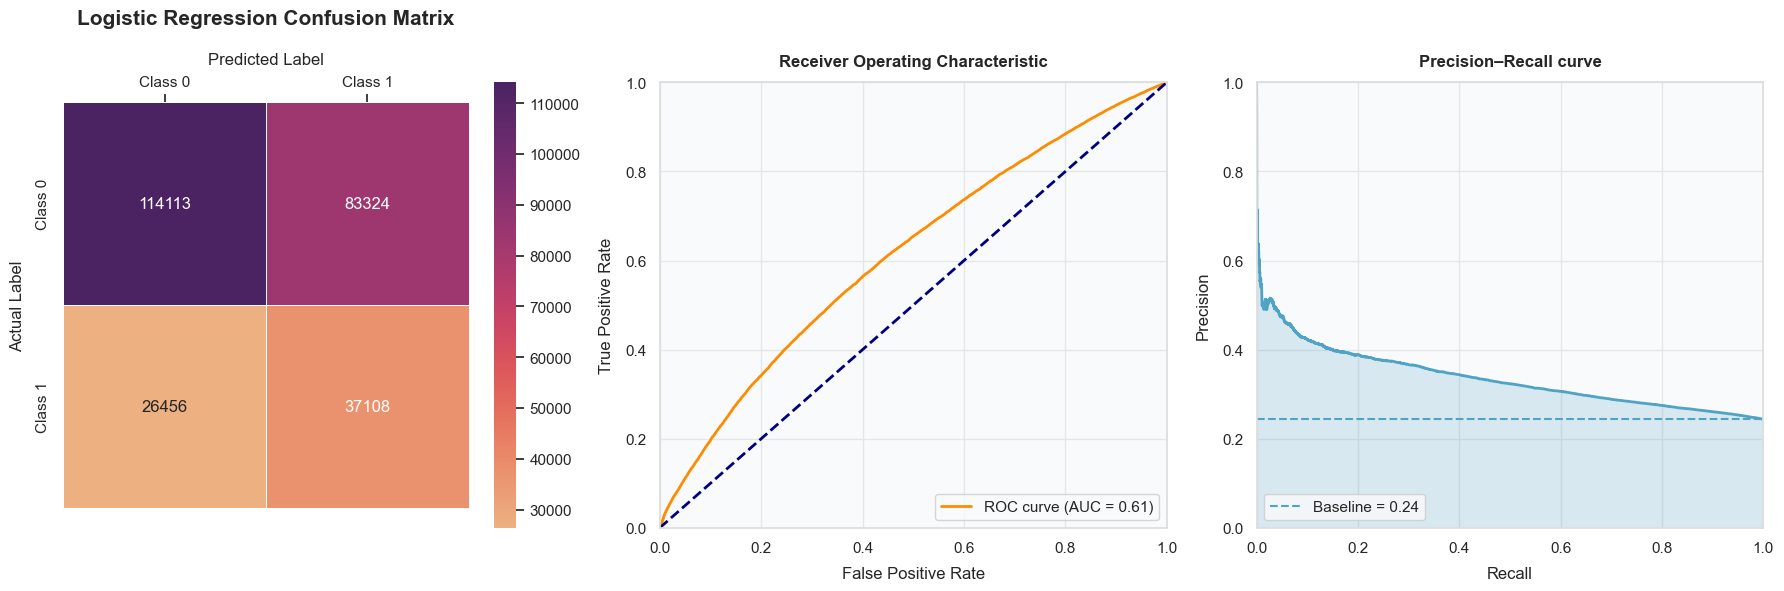


Confusion Matrix (train):
 [[114113  83324]
 [ 26456  37108]]


In [39]:
show_evaluation_metrics_train('Logistic Regression', y_train, y_train_pred_log_reg, y_train_proba_log_reg)

<h3>3.3. Gridsearch optimal parameters</h3>

In [40]:
# 1. Create a pipeline with a scaler and the model
# StandardScaler is a common and often effective choice

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-fold cross-validation
# Metric to optimize
scoring = {"recall": "recall", "precision": "precision", "ap": "average_precision"}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(solver="saga", max_iter=4000, random_state=42, class_weight='balanced'))
])

# 2. Define the parameter grid for the grid search
lr_params = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__l1_ratio': [0.0, 1.0],
}

# 3. Initialize and fit GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=pipe, 
    param_grid=lr_params, 
    cv=cv, 
    scoring=scoring, # Metric to optimize
    refit="ap",
    n_jobs=-1,
    verbose = 1)

In [41]:
# Perform grid search on the training set
grid_search_lr.fit(X_train, y_train)

# View the results
print("\n--- Results ---")
print(f"Best hyperparameters found: {grid_search_lr.best_params_}")
print(f"Best average precision score: {grid_search_lr.best_score_:.3f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

--- Results ---
Best hyperparameters found: {'lr__C': 0.001, 'lr__l1_ratio': 1.0}
Best average precision score: 0.337


In [42]:
results = grid_search_lr.cv_results_
best_i = grid_search_lr.best_index_

print("Best params:", grid_search_lr.best_params_)
print("CV AP (best):", results["mean_test_ap"][best_i])
print("CV Recall (best):", results["mean_test_recall"][best_i])
print("CV Precision (best):", results["mean_test_precision"][best_i])

Best params: {'lr__C': 0.001, 'lr__l1_ratio': 1.0}
CV AP (best): 0.3365865287945244
CV Recall (best): 0.5824522979282616
CV Precision (best): 0.307332962115509


<h3>3.4. Score on test set</h3>

In [43]:
# Use the best estimator to make predictions on the test set
best_model_log_reg = grid_search_lr.best_estimator_
y_test_pred_log_reg = best_model_log_reg.predict(X_test)
y_test_proba_log_reg = best_model_log_reg.predict_proba(X_test)[:, 1]

=== Testing Performance: Logistic Regression ===
Precision–Recall AUC (test): 0.2891
Recall (Delayed Flights)(test): 0.6479
Precision(test): 0.2576
ROC AUC (test): 0.6219

Classification Report (test):
               precision    recall  f1-score   support

           0       0.85      0.52      0.65     68106
           1       0.26      0.65      0.37     17329

    accuracy                           0.55     85435
   macro avg       0.56      0.59      0.51     85435
weighted avg       0.73      0.55      0.59     85435



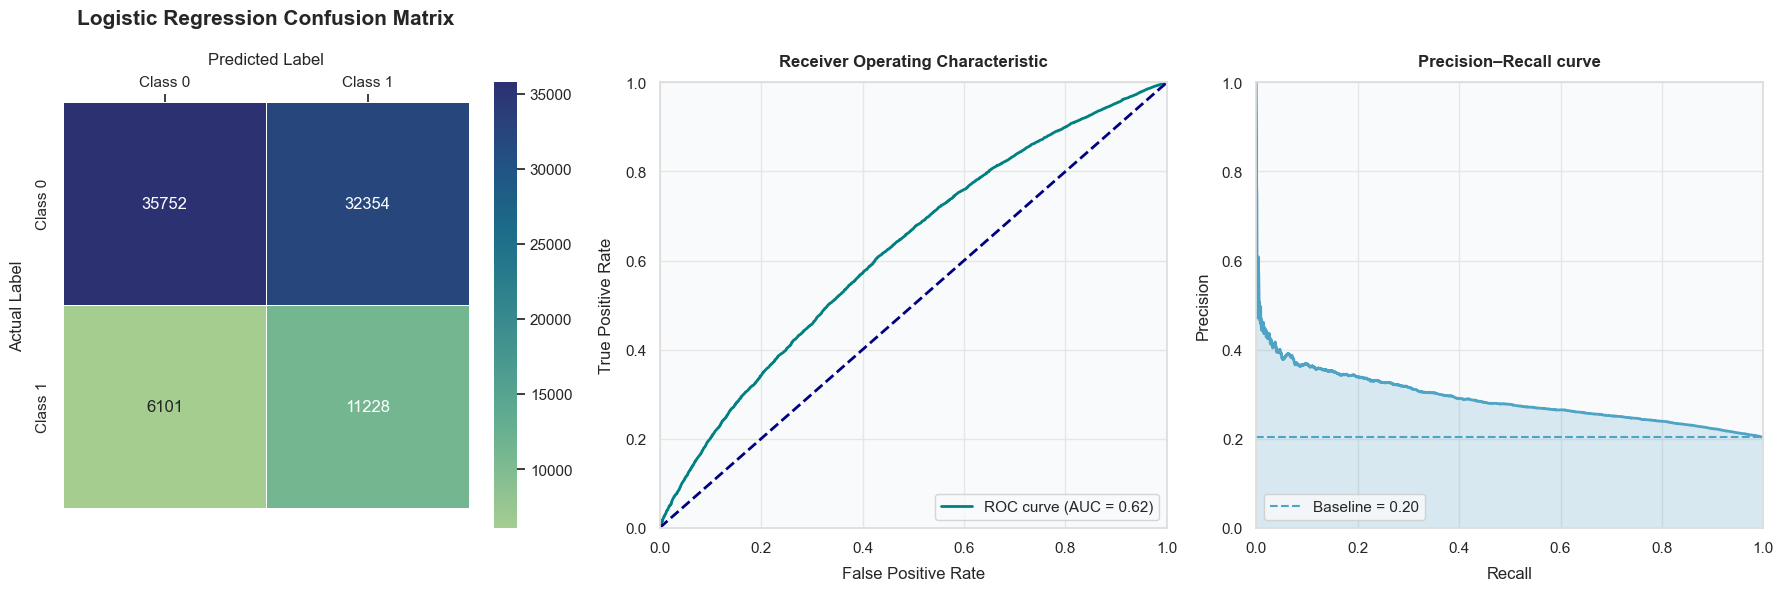


Confusion Matrix (test):
 [[35752 32354]
 [ 6101 11228]]


In [44]:
show_evaluation_metrics_test ('Logistic Regression', y_test, y_test_pred_log_reg, y_test_proba_log_reg)

In [45]:
log_results(
    "Logistic Regression",
    y_test, y_test_pred_log_reg, y_test_proba_log_reg
)

,Model,Recall_Pos,PR_AUC,ROC_AUC,Precision_Pos,F1_Pos,Balanced_Acc,Accuracy,TP,FP,TN,FN
0,Logistic Regression,0.647931,0.289057,0.621925,0.257629,0.368669,0.586439,0.549892,11228,32354,35752,6101


In [46]:
feature_names = X_train.columns
coef = best_model_log_reg.named_steps['lr'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef)
}).sort_values('abs_coefficient', ascending=False)

coef_df.head(10)      # strongest positive drivers

,feature,coefficient,abs_coefficient
3,wspd,0.157064,0.157064
8,wdir_cos,-0.130881,0.130881
7,wdir_sin,0.090055,0.090055
1,rhum,-0.088997,0.088997
0,temp,0.082294,0.082294
4,pres,-0.082094,0.082094
21,coco_14,0.057682,0.057682
6,cldc_missing,0.050901,0.050901
11,coco_2,-0.050301,0.050301
15,coco_7,0.048801,0.048801


In [47]:
# Sparsity 
n_nonzero = np.sum(coef != 0)
total = len(coef)

print(f"{n_nonzero}/{total} features retained ({n_nonzero/total:.1%})")

17/27 features retained (63.0%)


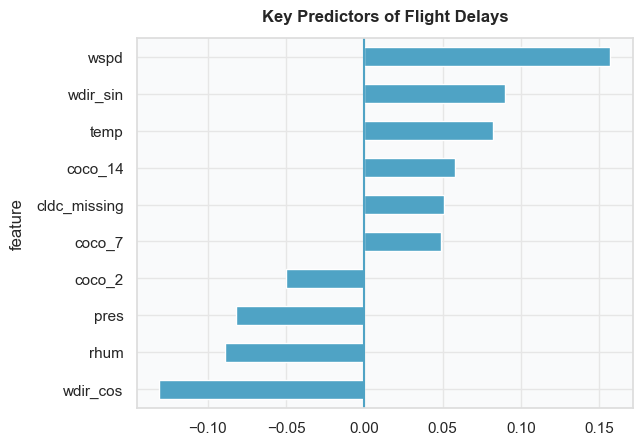

In [48]:
coef_df.head(10).sort_values('coefficient').plot.barh(
    x='feature',
    y='coefficient',
    legend=False
)
plt.axvline(0)
plt.title("Key Predictors of Flight Delays")
plt.show()

<b>Observations: </b>
- The Logistic Regression model was tuned using GridSearchCV and evaluated on a temporally separated 2025 validation dataset to approximate real-world deployment conditions.
- The model achieved a recall of 0.65 for delayed flights, indicating strong detection capability. This was accompanied by a Precision–Recall AUC of 0.289, representing a meaningful improvement over the baseline delay rate of approximately 20%.
- Precision for delayed flights was 0.26, roughly 30% higher than baseline, confirming that the model provides useful predictive signal despite class imbalance.
- As anticipated, the model generated a relatively high number of false positives. This reflects an intentional modelling choice prioritising delay detection, based on the assumption that missing a delay carries greater operational risk than issuing a false alert.
- Examination of model coefficients provides insight into the primary drivers of flight delays:
    - Wind speed emerged as the strongest positive predictor, aligning with operational expectations that severe wind conditions disrupt flight schedules.
    - Wind direction features also demonstrated meaningful influence, suggesting that specific directional patterns may contribute to air traffic constraints. Temperature showed a positive association with delays, while higher atmospheric pressure and relative humidity were linked to more stable conditions and reduced delay likelihood.
    - Notably, the indicator for missing cloud cover data was retained by the model, implying that gaps in weather reporting may themselves signal adverse conditions.
    - The use of L1 regularization resulted in approximately 37% of features being eliminated, enhancing model interpretability while preserving predictive signal.
- Overall, the results suggest that the model captures stable predictive relationships that generalise across time. Logistic Regression therefore serves as a strong, interpretable baseline against which more complex models will be evaluated.

<h2>4. Decision Trees</h2>

<h3>4.1. Use Decision Trees</h3>

In [49]:
# instantiate the model for decision tree baseline
decision_tree_model = train_model(DecisionTreeClassifier, X_train, y_train, random_state=42, class_weight='balanced')

<h3>4.2. Score on training set</h3>

In [50]:
print(decision_tree_model.get_depth())
print(decision_tree_model.get_n_leaves())

36
13553


In [51]:
# Evaluate model against training set
y_train_pred_dt = decision_tree_model.predict(X_train)
y_train_proba_dt = decision_tree_model.predict_proba(X_train)[:, 1]

=== Training Performance: Decision Tree ===
Precision–Recall AUC (train): 0.5302
Recall (Delayed Flights)(test): 0.6862
Precision(test): 0.4102
ROC AUC (train): 0.7573

Classification Report (train):
               precision    recall  f1-score   support

           0       0.87      0.68      0.77    197437
           1       0.41      0.69      0.51     63564

    accuracy                           0.68    261001
   macro avg       0.64      0.68      0.64    261001
weighted avg       0.76      0.68      0.70    261001



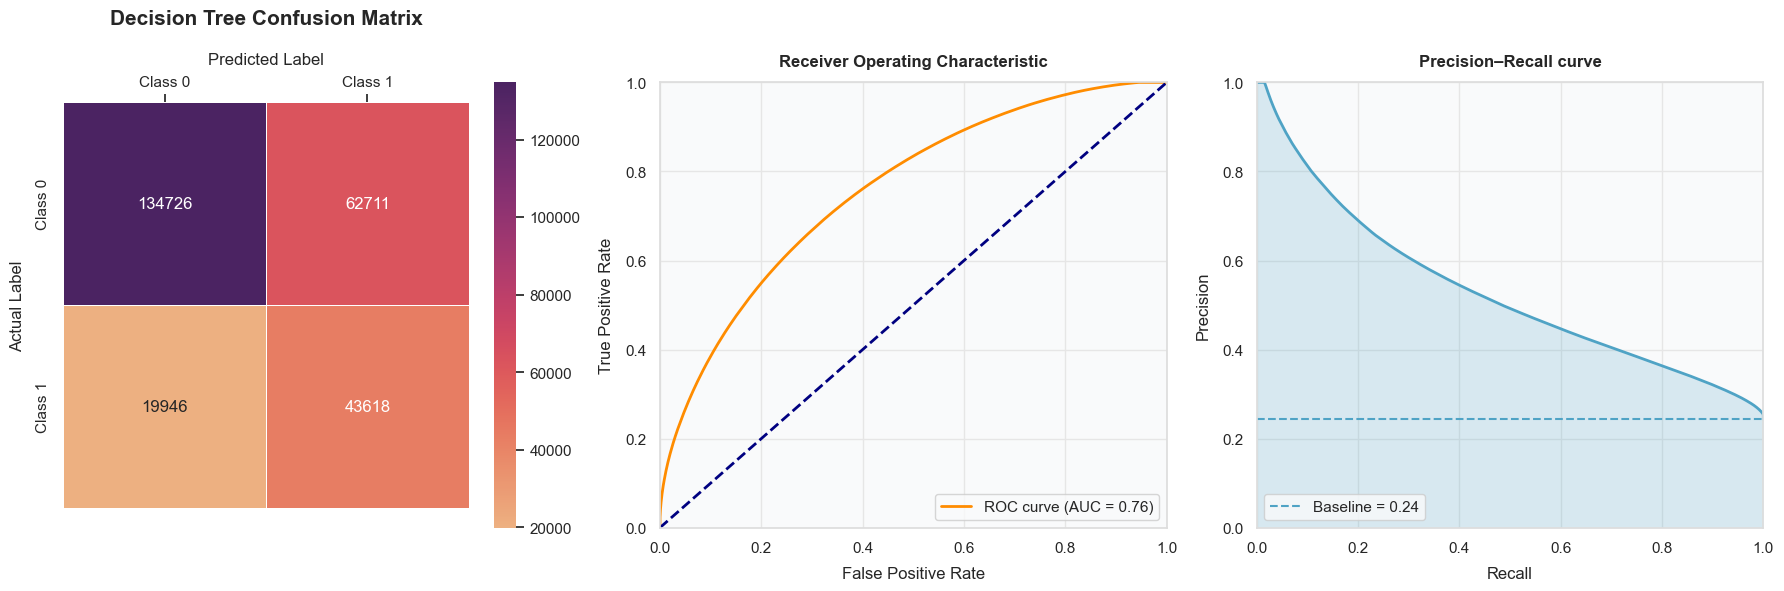


Confusion Matrix (train):
 [[134726  62711]
 [ 19946  43618]]


In [52]:
# Training set evaluation
show_evaluation_metrics_train ('Decision Tree', y_train, y_train_pred_dt, y_train_proba_dt)

- Since decision trees do not require scaled data, we fit the model on X_train
- The recall for class 1 'delayed_15' is low, the model is only capturing 23% of the cases

<h3>4.3. Gridsearch optimal parameters</h3>

In [53]:
# Define the parameter grid to tune the hyperparameters

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"recall": "recall", "precision": "precision", "ap": "average_precision"}

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_split': [200, 500, 1000],
    'min_samples_leaf': [50, 100, 200, 500],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 1e-4, 1e-3]
}

dtree = DecisionTreeClassifier(random_state=42, class_weight='balanced') # Initialize a decision tree 

# 3. Perform Grid Search
# The GridSearchCV object systematically tries all combinations with 5-fold cross-validation (cv=5).
# n_jobs=-1 uses all available CPU cores for parallel processing, speeding up the search.
grid_search_dt = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid_dt,
    cv=cv,
    scoring=scoring, # Metric to optimize
    refit="ap",
    n_jobs=-1,
    verbose=1
)

In [54]:
# Perform grid search on the training set
grid_search_dt.fit(X_train, y_train)

best_i = grid_search_dt.best_index_
res = grid_search_dt.cv_results_

# View the results
print("\n--- Results ---")
print(f"Best hyperparameters found: {grid_search_dt.best_params_}")
print(f"Best score: {grid_search_dt.best_score_:.3f}")
print("CV AP:", res["mean_test_ap"][best_i])
print("CV Recall:", res["mean_test_recall"][best_i])
print("CV Precision:", res["mean_test_precision"][best_i])

Fitting 5 folds for each of 1080 candidates, totalling 5400 fits

--- Results ---
Best hyperparameters found: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 12, 'max_features': None, 'min_samples_leaf': 50, 'min_samples_split': 200}
Best score: 0.393
CV AP: 0.39287798215478464
CV Recall: 0.5453557175533812
CV Precision: 0.34376929971317244


<h3>4.4. Score on test set</h3>

In [55]:
# Use the best estimator to make predictions on the test set
best_dt_model = grid_search_dt.best_estimator_
y_test_pred_dt_best = best_dt_model.predict(X_test)
y_test_proba_dt_best = best_dt_model.predict_proba(X_test)[:, 1]

In [56]:
print("Depth:", best_dt_model.get_depth())
print("Leaves:", best_dt_model.get_n_leaves())

Depth: 12
Leaves: 798


=== Testing Performance: Decision Tree ===
Precision–Recall AUC (test): 0.2686
Recall (Delayed Flights)(test): 0.5434
Precision(test): 0.2502
ROC AUC (test): 0.5930

Classification Report (test):
               precision    recall  f1-score   support

           0       0.83      0.59      0.69     68106
           1       0.25      0.54      0.34     17329

    accuracy                           0.58     85435
   macro avg       0.54      0.56      0.52     85435
weighted avg       0.72      0.58      0.62     85435



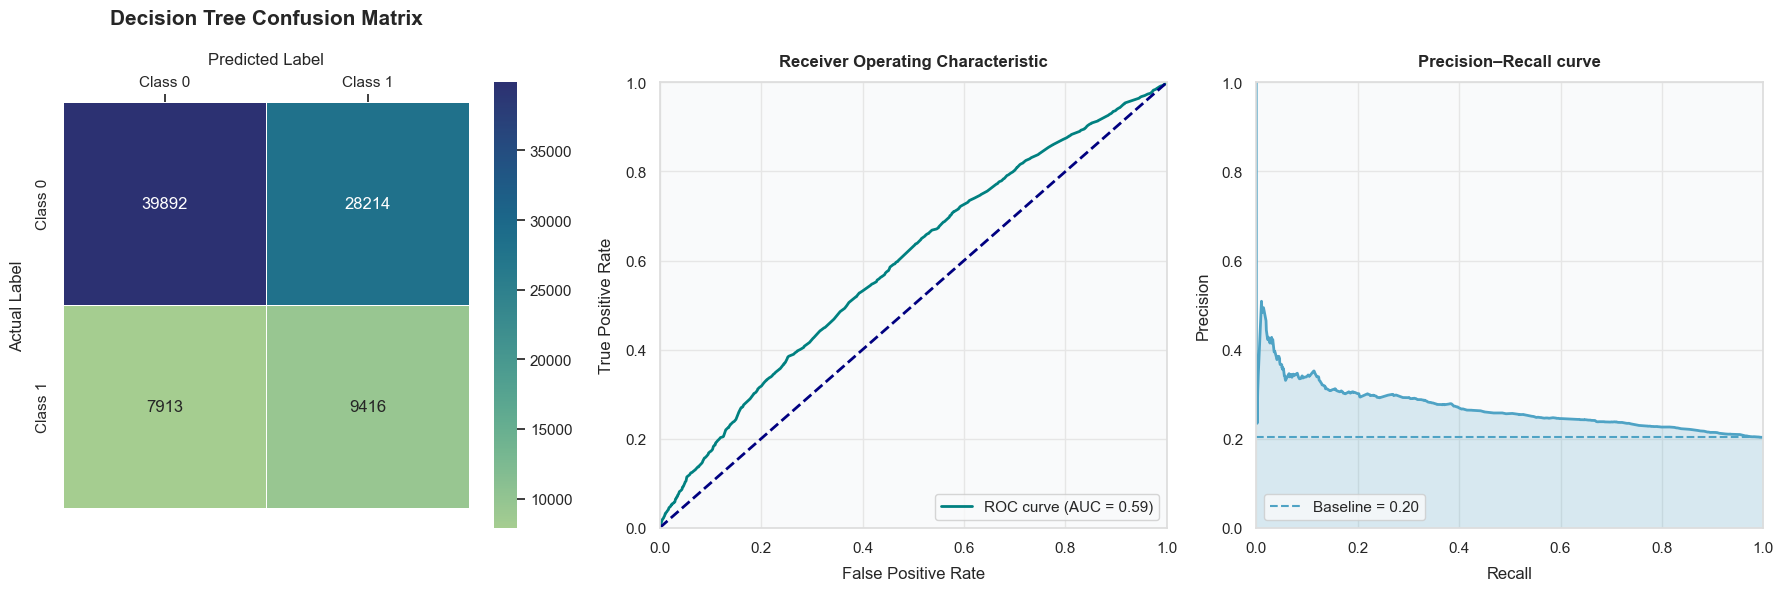


Confusion Matrix (test):
 [[39892 28214]
 [ 7913  9416]]


In [57]:
# Test set evaluation
show_evaluation_metrics_test ('Decision Tree', y_test, y_test_pred_dt_best, y_test_proba_dt_best)

In [58]:
log_results(
    'Decision Tree', y_test, y_test_pred_dt_best, y_test_proba_dt_best
)

,Model,Recall_Pos,PR_AUC,ROC_AUC,Precision_Pos,F1_Pos,Balanced_Acc,Accuracy,TP,FP,TN,FN
0,Logistic Regression,0.647931,0.289057,0.621925,0.257629,0.368669,0.586439,0.549892,11228,32354,35752,6101
1,Decision Tree,0.543367,0.268641,0.593008,0.250226,0.342655,0.564550,0.577141,9416,28214,39892,7913


<b>Observations:</b>
- Although the Decision Tree demonstrated strong cross-validation performance, its effectiveness declined on the temporally separated 2025 dataset.
- Compared with Logistic Regression, the tree produced fewer false positives but failed to identify a larger proportion of delayed flights, resulting in lower recall (0.54 vs 0.65) and reduced Precision–Recall AUC (0.269 vs 0.289).
- Given the project’s objective prioritises delay detection over false alarms, Logistic Regression provides a more suitable operational trade-off.
- The results suggest that the simpler linear model captures relationships that generalise more reliably across time, whereas the tree’s additional complexity may have introduced variance that did not persist into future data.

<h2>5. Random Forests</h2>

<h3>5.1. Use Random Forests</h3>

In [59]:
# instantiate the model 
rf_model = train_model(RandomForestClassifier, X_train, y_train, random_state=42, n_estimators=1000, criterion='gini',  max_depth=3, class_weight='balanced')

<h3>5.2. Score on training set</h3>


In [60]:
# Evaluate model against training set
y_train_pred_rf = rf_model.predict(X_train)
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]


=== Training Performance: Random Forest ===
Precision–Recall AUC (train): 0.3406
Recall (Delayed Flights)(test): 0.5498
Precision(test): 0.3114
ROC AUC (train): 0.6136

Classification Report (train):
               precision    recall  f1-score   support

           0       0.81      0.61      0.69    197437
           1       0.31      0.55      0.40     63564

    accuracy                           0.59    261001
   macro avg       0.56      0.58      0.55    261001
weighted avg       0.69      0.59      0.62    261001



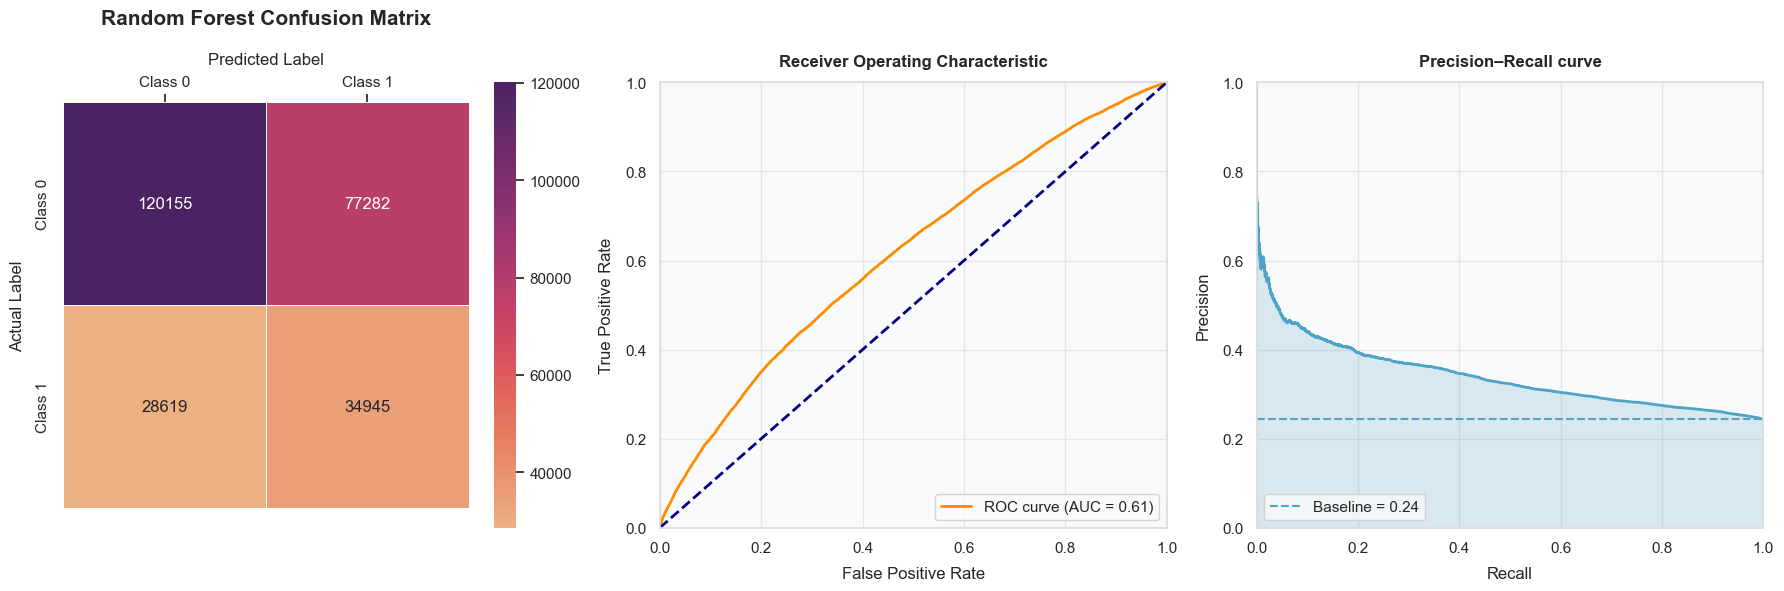


Confusion Matrix (train):
 [[120155  77282]
 [ 28619  34945]]


In [61]:
# Training set evaluation
show_evaluation_metrics_train ('Random Forest', y_train, y_train_pred_rf, y_train_proba_rf)

<b>Observations: </b>
- max_depth=3 → very shallow trees, so strong bias, low variance. “With shallow trees, the forest behaves almost like a linear model.”

<h3>5.3. Gridsearch optimal parameters</h3>

In [62]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-fold cross-validation

scoring = {"recall": "recall", "precision": "precision", "ap": "average_precision"}

# Define the parameter grid for the grid search
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [3, None, 10, 15, 20],
    'min_samples_split': [50, 200],
    'min_samples_leaf': [200, 500],
    'max_features': ['sqrt', 'log2'],
}

rf=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)

# 3. Initialize and fit GridSearchCV
# The GridSearchCV object systematically tries all combinations with 5-fold cross-validation (cv=5).
# n_jobs=-1 uses all available CPU cores for parallel processing, speeding up the search.
grid_search_rf = GridSearchCV(
    rf, 
    param_grid=param_grid_rf, 
    cv=cv,
    scoring = scoring,
    refit="ap",
    n_jobs=2, #parallelise GridSearch modestly; keep RF single-core
    verbose=1
)

In [63]:
# Perform grid search on the training set
grid_search_rf.fit(X_train, y_train)

# View the results
print("\n--- Results ---")
print(f"Best hyperparameters found: {grid_search_rf.best_params_}")
print(f"Best average precision score: {grid_search_rf.best_score_:.3f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits

--- Results ---
Best hyperparameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 200, 'min_samples_split': 50, 'n_estimators': 100}
Best average precision score: 0.388


In [64]:
best_i = grid_search_rf.best_index_
res = grid_search_rf.cv_results_
print("CV AP:", res["mean_test_ap"][best_i])
print("CV Recall:", res["mean_test_recall"][best_i])
print("CV Precision:", res["mean_test_precision"][best_i])

CV AP: 0.38817504265164604
CV Recall: 0.5745073772990061
CV Precision: 0.3438701429349421


<h3>5.4. Score on test set</h3>

In [65]:
#Predict the response for test dataset
best_model_rf = grid_search_rf.best_estimator_

y_test_pred_rf_best = best_model_rf.predict(X_test)
y_test_proba_rf_best = best_model_rf.predict_proba(X_test)[:, 1]

=== Testing Performance: Random Forest ===
Precision–Recall AUC (test): 0.3244
Recall (Delayed Flights)(test): 0.5967
Precision(test): 0.2772
ROC AUC (test): 0.6425

Classification Report (test):
               precision    recall  f1-score   support

           0       0.85      0.60      0.71     68106
           1       0.28      0.60      0.38     17329

    accuracy                           0.60     85435
   macro avg       0.57      0.60      0.54     85435
weighted avg       0.74      0.60      0.64     85435



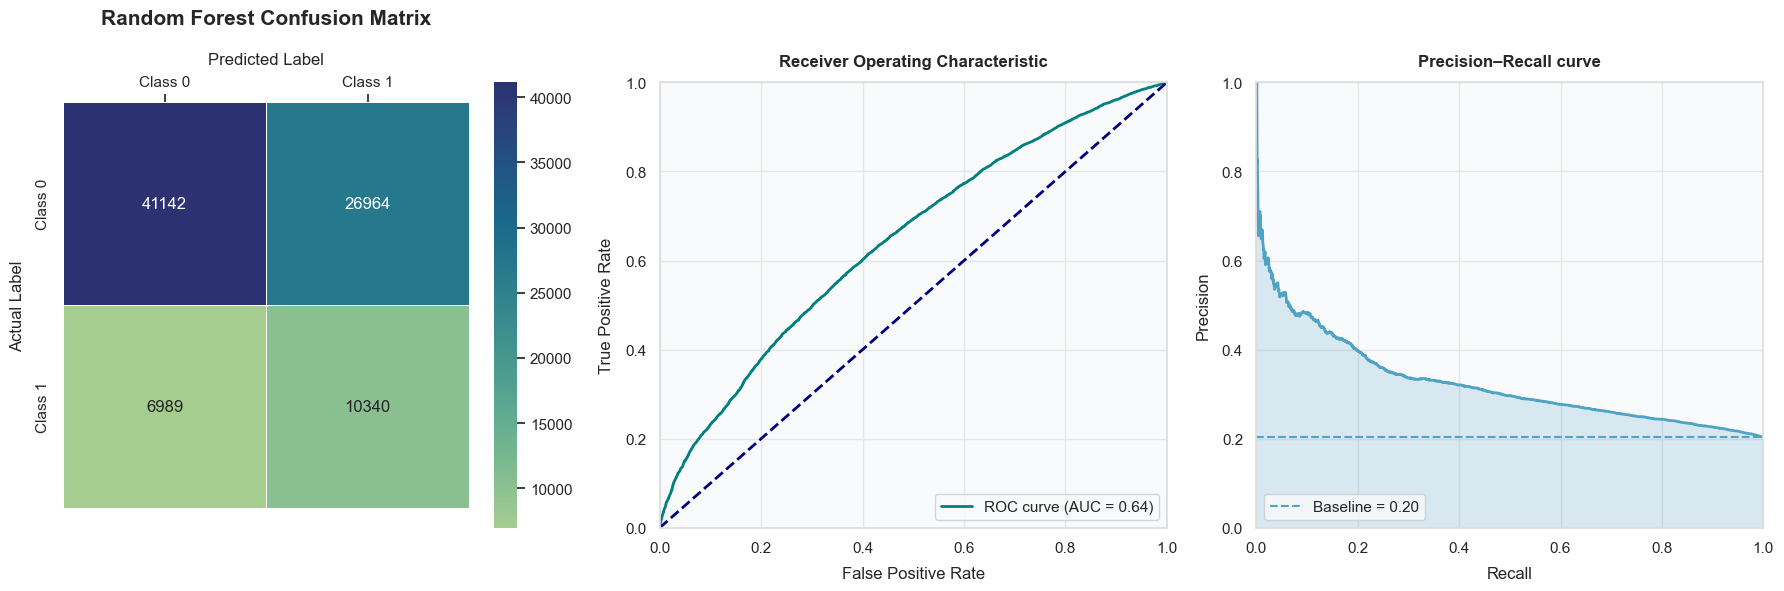


Confusion Matrix (test):
 [[41142 26964]
 [ 6989 10340]]


In [66]:
# Test set evaluation
show_evaluation_metrics_test ('Random Forest', y_test, y_test_pred_rf_best, y_test_proba_rf_best)

In [67]:
log_results(
    'Random Forest', y_test, y_test_pred_rf_best, y_test_proba_rf_best
)

,Model,Recall_Pos,PR_AUC,ROC_AUC,Precision_Pos,F1_Pos,Balanced_Acc,Accuracy,TP,FP,TN,FN
0,Logistic Regression,0.647931,0.289057,0.621925,0.257629,0.368669,0.586439,0.549892,11228,32354,35752,6101
1,Decision Tree,0.543367,0.268641,0.593008,0.250226,0.342655,0.564550,0.577141,9416,28214,39892,7913
2,Random Forest,0.596688,0.324412,0.642492,0.277182,0.378526,0.600388,0.602587,10340,26964,41142,6989


In [68]:
model_results

,Model,Recall_Pos,PR_AUC,ROC_AUC,Precision_Pos,F1_Pos,Balanced_Acc,Accuracy,TP,FP,TN,FN
0,Logistic Regression,0.647931,0.289057,0.621925,0.257629,0.368669,0.586439,0.549892,11228,32354,35752,6101
1,Decision Tree,0.543367,0.268641,0.593008,0.250226,0.342655,0.564550,0.577141,9416,28214,39892,7913
2,Random Forest,0.596688,0.324412,0.642492,0.277182,0.378526,0.600388,0.602587,10340,26964,41142,6989


<h3>4.4. Feature Importance</h3>

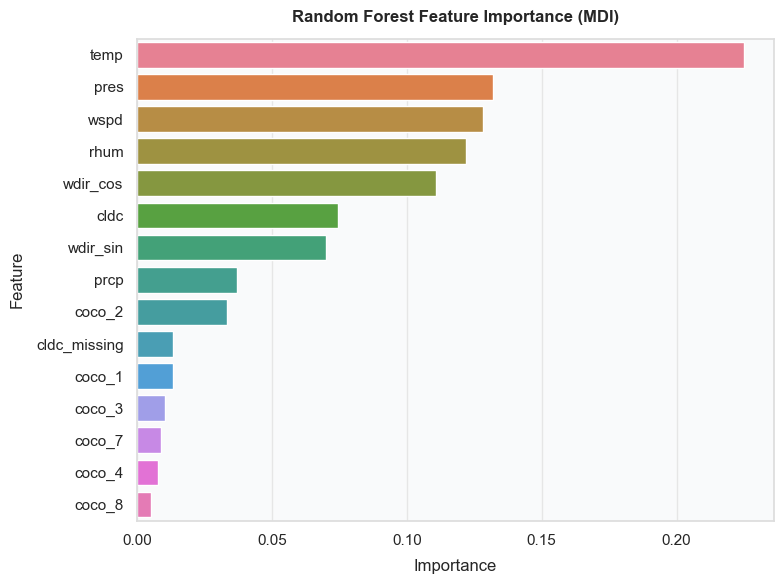

In [69]:
# how much each feature contributes to reducing impurity in decision trees
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp.head(15),
    x='importance',
    y='feature',
    hue='feature',
    legend=False
)
plt.title('Random Forest Feature Importance (MDI)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

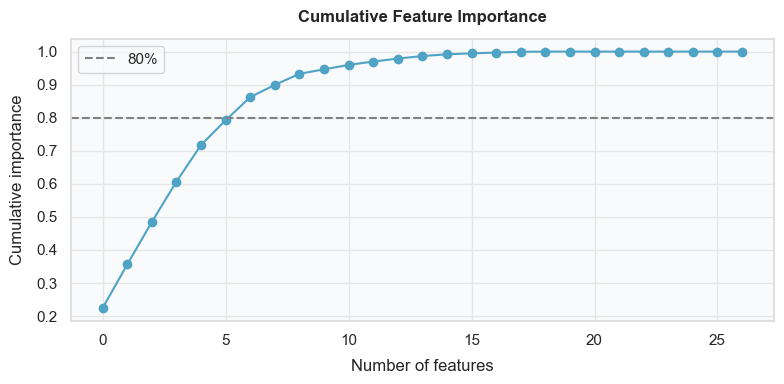

In [70]:
feat_imp['cum_importance'] = feat_imp['importance'].cumsum()

plt.figure(figsize=(8, 4))
plt.plot(feat_imp['cum_importance'].values, marker='o')
plt.axhline(0.8, linestyle='--', color='grey', label='80%')
plt.xlabel('Number of features')
plt.ylabel('Cumulative importance')
plt.title('Cumulative Feature Importance')
plt.legend()
plt.tight_layout()
plt.show()

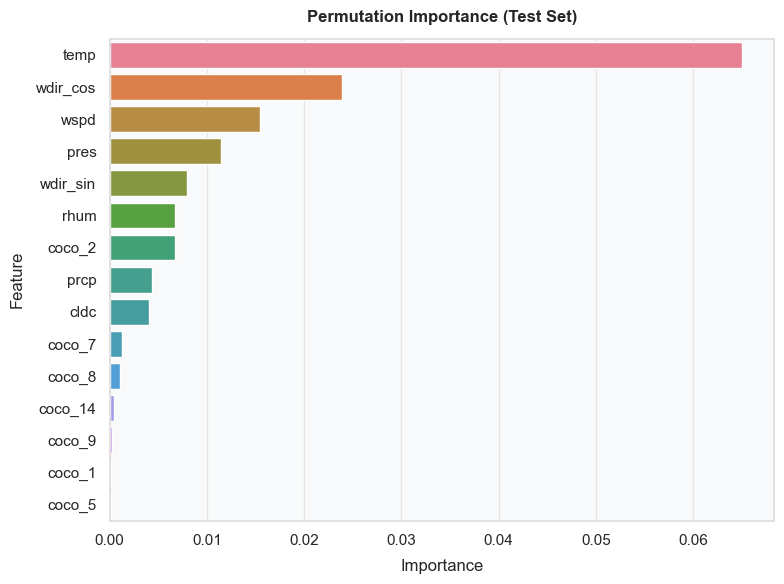

In [71]:
# What actually hurts test performance when this feature is destroyed?

perm = permutation_importance(
    best_model_rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='average_precision'  # or recall_pos
)

perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=perm_imp.head(15),
    x='importance',
    y='feature',
    hue='feature',
    legend=False
)
plt.title('Permutation Importance (Test Set)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

<b>Observations:</b>
- The tuned Random Forest delivered the strongest overall performance on the temporally separated 2025 dataset, achieving a Precision–Recall AUC of 0.324, the highest among all evaluated models.
- While recall (0.60) was slightly lower than Logistic Regression (0.65), the forest substantially reduced false positives, improving precision to 0.28 and providing a more balanced operational trade-off.
- These results suggest that the ensemble effectively captures nonlinear relationships while maintaining the stability required for future generalization.
- Features that contribute most to reducing impurity in decision trees are temperature, pressure, wind speed, wind direction and humidity are the primary drivers of predicted delay risk. That combination often signals storm systems.
- Cumulative Feature Importance graph indicates that approx. 80% of total importance is captured by 5 features. After 10 features, gains are marginal.
- The  Permutation Importance graph confirms that a small set of continuous meteorological variables accounts for most of the model’s predictive power, with temperature contributing the largest marginal effect. 

<h2>6. XGBoost</h2>

<h3>6.1. Use XGBoost</h3>

In [72]:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos  # imbalance handling

In [73]:
# 1) Train/val split (from training only)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# 2) Convert to DMatrix (native XGBoost format)
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test, label=y_test)

In [74]:
# instantiate the model 
params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "eta": 0.05,                 # learning_rate
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,               # reg_lambda
    "alpha": 0.0,                # reg_alpha
    "gamma": 0.0,
    "scale_pos_weight": scale_pos_weight,
    "tree_method": "hist",
    "max_delta_step": 1,
    "seed": 42
}

In [75]:
# 4) Train with early stopping
evals = [(dtrain, "train"), (dval, "val")]
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=False
)

print("Best iteration:", bst.best_iteration)

Best iteration: 2555


<h3>6.2. Score on test set</h3>

In [76]:
#Predict the response for test dataset
y_test_proba_xgb = bst.predict(
    dtest,
    iteration_range=(0, bst.best_iteration + 1)
)

y_test_pred_xgb = (y_test_proba_xgb >= 0.5).astype(int)

=== Testing Performance: XGBoost ===
Precision–Recall AUC (test): 0.3035
Recall (Delayed Flights)(test): 0.5468
Precision(test): 0.2730
ROC AUC (test): 0.6258

Classification Report (test):
               precision    recall  f1-score   support

           0       0.85      0.63      0.72     68106
           1       0.27      0.55      0.36     17329

    accuracy                           0.61     85435
   macro avg       0.56      0.59      0.54     85435
weighted avg       0.73      0.61      0.65     85435



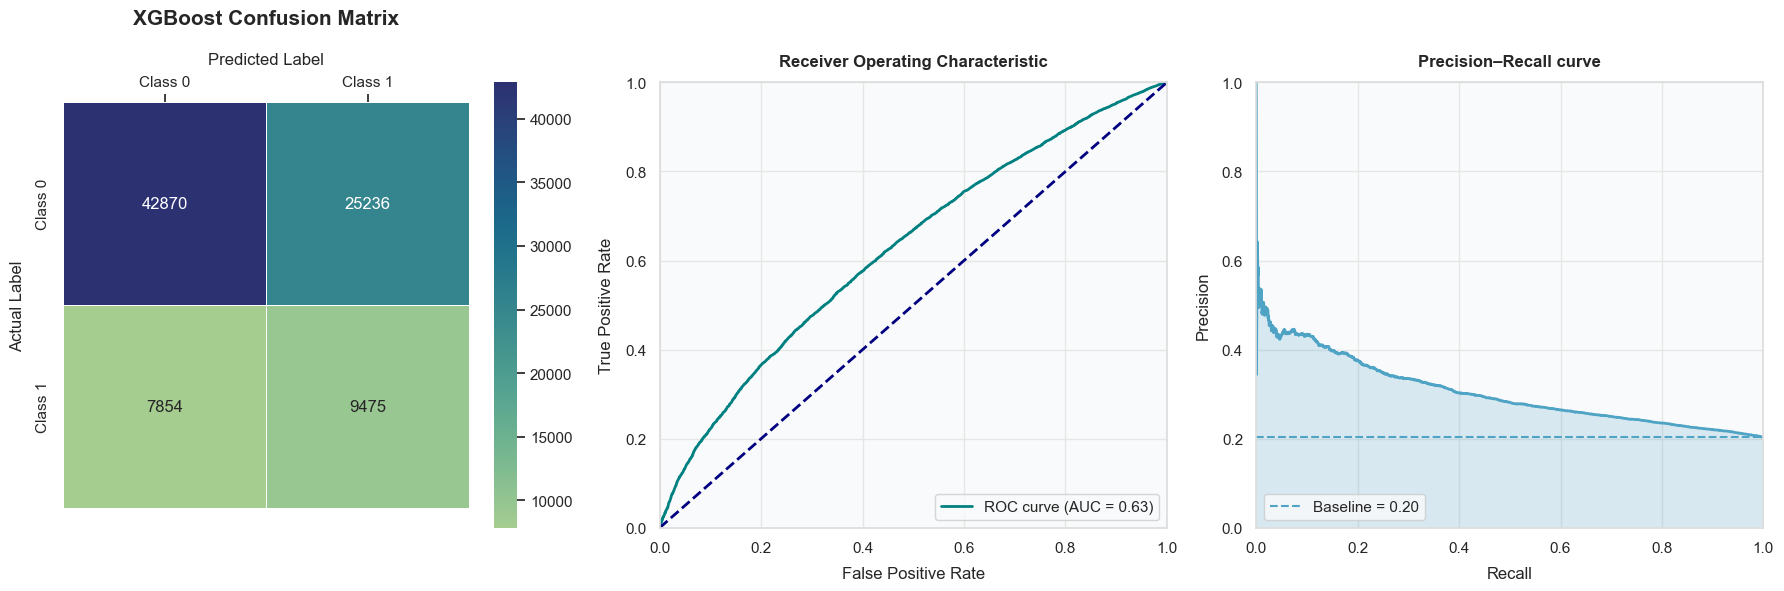


Confusion Matrix (test):
 [[42870 25236]
 [ 7854  9475]]


In [77]:
# Test set evaluation
show_evaluation_metrics_test ('XGBoost', y_test, y_test_pred_xgb, y_test_proba_xgb)

<b>Observations:</b>
- While gradient boosting demonstrated competitive performance, it did not surpass the tuned Random Forest on temporally separated data. The Random Forest improves delay detection by roughly 9% relative to XGBoost, while increasing false positives by about 7%. Given that missed delays typically carry greater operational risk than unnecessary alerts, this represents a favourable trade-off.

In [78]:
log_results(
    'XGBoost', y_test, y_test_pred_xgb, y_test_proba_xgb
)

,Model,Recall_Pos,PR_AUC,ROC_AUC,Precision_Pos,F1_Pos,Balanced_Acc,Accuracy,TP,FP,TN,FN
0,Logistic Regression,0.647931,0.289057,0.621925,0.257629,0.368669,0.586439,0.549892,11228,32354,35752,6101
1,Decision Tree,0.543367,0.268641,0.593008,0.250226,0.342655,0.564550,0.577141,9416,28214,39892,7913
2,Random Forest,0.596688,0.324412,0.642492,0.277182,0.378526,0.600388,0.602587,10340,26964,41142,6989
3,XGBoost,0.546771,0.303495,0.625768,0.272968,0.364143,0.588116,0.612688,9475,25236,42870,7854


In [79]:
model_results = (
    model_results
    .sort_values(by=["PR_AUC", "Recall_Pos"], ascending=False)
    .reset_index(drop=True)
    .round(2)
)

In [80]:
model_results

,Model,Recall_Pos,PR_AUC,ROC_AUC,Precision_Pos,F1_Pos,Balanced_Acc,Accuracy,TP,FP,TN,FN
0,Random Forest,0.60,0.32,0.64,0.28,0.38,0.60,0.60,10340,26964,41142,6989
1,XGBoost,0.55,0.30,0.63,0.27,0.36,0.59,0.61,9475,25236,42870,7854
2,Logistic Regression,0.65,0.29,0.62,0.26,0.37,0.59,0.55,11228,32354,35752,6101
3,Decision Tree,0.54,0.27,0.59,0.25,0.34,0.56,0.58,9416,28214,39892,7913


In [81]:
comparison_df = test_df.copy()

comparison_df["predicted_delay"] = y_test_pred_rf_best
comparison_df["weather_delay"] = (comparison_df["weather_delay"] > 0).astype(int)

pd.crosstab(
    comparison_df["weather_delay"],
    comparison_df["predicted_delay"],
    rownames=["Actual Weather Delay"],
    colnames=["Predicted Delay"]
)

Predicted Delay,0,1
Actual Weather Delay,,
0,47996,36795
1,135,509


In [82]:
weather_precision = (
    comparison_df
    .query("predicted_delay == 1")["weather_delay"]
    .mean()
)

weather_precision

np.float64(0.01364464936736007)

In [83]:
weather_recall = recall_score(
    comparison_df["weather_delay"],
    comparison_df["predicted_delay"]
)

weather_recall

0.7903726708074534

A comparison with the Weather Delay indicator shows high recall, suggesting the model captures the majority of explicitly weather-related delays.
Lower precision is expected, as many weather-induced disruptions are recorded under other delay categories, such as late aircraft arrival or carrier delays

<h2>7. Conclusions</h2>

The objective of this project is to examine the extent to which weather conditions influence the likelihood of flight departure delays and to develop a predictive model using combined flight and meteorological data. We explored several machine learning models, training them on 2022-2023 flights data for JFK and testing them on the January - October 2025 flights data for JFK, concentrating on the delays at gate only. 

The Random Forest model proved to offer best balance between maximising the number of predicted delays and false positives. Whilst the Random Forest does not capture every event, many flight disruptions stem from factors beyond weather — such as inbound aircraft delays or carrier-related constraints — which were outside the scope of this model. Therefore, we will accept these results and recommend the Random Forest model as our model of choice. 

The model developed in this project could serve as a helpful tool in detecting upcoming flight departure delays linked to weather conditions for the JFK airport, and it could reduce the pressures and costs associated with flight delays, at the departure airport itself or further down the network.

Final output could be a dashboard with upcoming flights information (e.g. 3-7 days out), with meteorological data merged in, and an indicator on which flights are at a risk of being delayed. Even if flights are flagged as at risk of being delayed closer to the departure time, this could allow the stakeholders to make the appropriate operational decisions to minimise the delay impact and costs. 

For next steps, we recommend: 
- Testing the model on other months, perhaps with a higher ratio of delayed flights
- Testing the model on other origins of departure to see how it holds
- Incorporating other predictors such as days of week, month, carrier, etc. 
